**VAD**

In [81]:
#@title Install and Import Dependencies

# this assumes that you have a relevant version of PyTorch installed
!pip install -q torchaudio
SAMPLING_RATE = 16000
import torch
torch.set_num_threads(1)
from IPython.display import Audio
from pprint import pprint
# download example
#torch.hub.download_url_to_file('https://models.silero.ai/vad_models/en.wav', 'en_example.wav')
!pip install faster-whisper
# Importamos el modulo faster_whister
from faster_whisper import WhisperModel
!pip install groq
! pip install -U pip
! pip install coqui-tts
import matplotlib.pyplot as plt
from TTS.api import TTS

In [82]:
audio= "upslasprisas.wav"

In [83]:
USE_PIP = True # download model using pip package or torch.hub
USE_ONNX = False # change this to True if you want to test onnx model
if USE_ONNX:
    !pip install -q onnxruntime
if USE_PIP:
  !pip install -q silero-vad
  from silero_vad import (load_silero_vad,
                          read_audio,
                          get_speech_timestamps,
                          save_audio,
                          VADIterator,
                          collect_chunks)
  VAD = load_silero_vad(onnx=USE_ONNX)
else:
  VAD, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                                model='silero_vad',
                                force_reload=True,
                                onnx=USE_ONNX)

  (get_speech_timestamps,
  save_audio,
  read_audio,
  VADIterator,
  collect_chunks) = utils

In [84]:
vad_iterator = VADIterator(VAD, sampling_rate=SAMPLING_RATE)
wav = read_audio(audio, sampling_rate=SAMPLING_RATE)

window_size_samples = 512 if SAMPLING_RATE == 16000 else 256
for i in range(0, len(wav), window_size_samples):
    chunk = wav[i: i+ window_size_samples]
    if len(chunk) < window_size_samples:
      break
    speech_dict = vad_iterator(chunk, return_seconds=True)
    if speech_dict:
        print(speech_dict, end=' ')
vad_iterator.reset_states() # reset model states after each audio

{'start': 0.8} {'end': 1.4} {'start': 1.8} {'end': 3.6} {'start': 4.0} {'end': 6.3} {'start': 6.8} {'end': 9.1} {'start': 10.1} {'end': 11.2} {'start': 12.4} {'end': 13.1} {'start': 13.7} {'end': 17.2} {'start': 17.8} {'end': 20.7} {'start': 21.2} {'end': 23.7} {'start': 26.1} {'end': 26.7} {'start': 26.9} {'end': 28.0} 

In [85]:
## just probabilities

wav = read_audio(audio, sampling_rate=SAMPLING_RATE)
speech_probs = []
window_size_samples = 512 if SAMPLING_RATE == 16000 else 256
for i in range(0, len(wav), window_size_samples):
    chunk = wav[i: i+ window_size_samples]
    if len(chunk) < window_size_samples:
      break
    speech_prob = VAD(chunk, SAMPLING_RATE).item()
    speech_probs.append(speech_prob)
vad_iterator.reset_states() # reset model states after each audio

print(speech_probs[:10]) # first 10 chunks predicts

[0.028851866722106934, 0.01583545282483101, 0.00836424995213747, 0.0077899545431137085, 0.006784891709685326, 0.0076948972418904305, 0.0077562700025737286, 0.006776099093258381, 0.0059366184286773205, 0.005513698793947697]


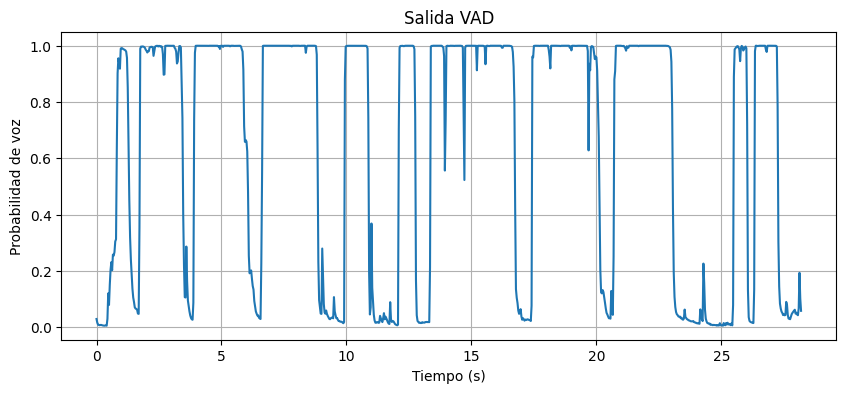

In [86]:
# %matplotlib inline ----- ACTIVAR EN CASO DE QUE NO FUNCIONE MATPLOTLIB
frame_duration = 0.03125

times = [i * frame_duration for i in range(len(speech_probs))]

plt.figure(figsize=(10,4))
plt.plot(times, speech_probs)

plt.xlabel("Tiempo (s)")
plt.ylabel("Probabilidad de voz")
plt.title("Salida VAD")
plt.grid()
plt.show()

In [87]:
# Especificamos el modelo
model_size = "base"

# Run on GPU with FP16
ASR = WhisperModel(model_size, device="cuda", compute_type="float16")

# or run on GPU with INT8
# model = WhisperModel(model_size, device="cuda", compute_type="int8_float16")
# or run on CPU with INT8
# model = WhisperModel(model_size, device="cpu", compute_type="int8")
#idioma = info.language
segments, info = ASR.transcribe(audio, beam_size=5)

In [88]:
text = [segment.text for segment in segments]
concatenated_text = " ".join(text)
concatenated_text

' Hola Drespie, mira que quería ver si me cuarta buena canción que me salió la letra antes  el arradio y no me acuerdo del nombre a ver si tú sabes, dices algo como prometo llevarte  en el foto de mi corazón, prometo recordarme siempre de cerrarlo de diciembre, ops perdón  las prisas.'

In [89]:
import os
os.environ["GROQ_API_KEY"] = "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"

In [90]:
import os

from groq import Groq

client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": concatenated_text,

        }
    ],
    model="llama-3.3-70b-versatile",
)

respuesta = chat_completion.choices[0].message.content

In [91]:
# Inicializar modelo (solo una vez)
#ts = TTS("tts_models/multilingual/multi-dataset/xtts_v2", gpu=True)
ts = TTS("tts_models/es/css10/vits", gpu=True)


In [92]:
ts = TTS("tts_models/es/css10/vits", gpu=True)
#if idioma == "ga": idioma = "es"

ts.tts_to_file(
    text=respuesta,
    #language=idioma,
    file_path="output.wav",
    #speaker_wav="etsemiau.wav"
)

'output.wav'